In [1]:
import os
import sys
import shutil
os.environ['TOKENIZERS_PARALLELISM'] = "False"

import torch
import pandas as pd
import numpy as np
import decord
import json
from IPython.display import display, Markdown, Latex
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
import PIL.Image
from glob import glob
from natsort import natsorted

from torch.utils.data import Dataset, DataLoader
from easydict import EasyDict as edict
import numpy as np
import json

import shared.utils as su
from utils.video import read_frames_decord
from utils.model import transform_pixel_values
from torchvision.transforms.v2 import (
    ToPILImage,
)
from models.modeling_encoders import AutoEncoder
from notebooks.eval_care_retrieval import load_model, load_data

In [101]:
# Load data
dataset = 'charades'
df = load_data(dataset)
df = df.drop_duplicates(subset=['id', 'text_id']).reset_index(drop=True)

# Chiral IDs
chiral_triplet_ids = df.chiral_triplet_id.unique()

df.shape

Number of rows:  5498
Sample row: 
{
    "id_base": "YSKX3",
    "subject": "CP6Y",
    "scene": "Bedroom",
    "quality": 5.0,
    "relevance": 6.0,
    "verified": "Yes",
    "length": 16.62,
    "cls_id": "c077",
    "template": "putting a pillow somewhere",
    "start_time": 12.1,
    "end_time": 16.62,
    "object_id": "o027",
    "noun": "na",
    "verb_id": "v016",
    "verb": "put",
    "label": "putting a pillow somewhere",
    "id": "YSKX3_12.1_16.6",
    "chiral_label": 0.0,
    "chiral_triplet_id": "a9be73ec",
    "text_id": "a9be73ec_0.0",
    "video_path": "/scratch/shared/beegfs/piyush/datasets/Charades/Charades_v1_480_cut_clips/YSKX3_12.1_16.6.mp4"
}


(5498, 21)

In [3]:
from models.modeling_encoders import EncoderForTarsier2

model_paths = {
    "Base": "/work/piyush/pretrained_checkpoints/Tarsier2-7b-0115",
    "Fine-tuned": "/work/piyush/experiments/CaRe/Tarsier2-7b-0115/covr/chiral10k-covr10k/merged_checkpoint",
}
models = {}
for k, v in model_paths.items():
    models[k] = EncoderForTarsier2.from_pretrained(
        v, dtype=torch.bfloat16, device_map="auto", attn_implementation="flash_attention_2",
    )

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading EncoderForTarsier2 from /work/piyush/pretrained_checkpoints/Tarsier2-7b-0115


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading EncoderForTarsier2 from /work/piyush/experiments/CaRe/Tarsier2-7b-0115/covr/chiral10k-covr10k/merged_checkpoint


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

### Time nuance (CiA)

In [102]:
# Load pre-computed embeddings

embed_dirs = {
    # "Base": "/work/piyush/pretrained_checkpoints/Tarsier-7b/embs",
    # "TARA": "/work/piyush/experiments/CaRe/Tarsier-7b/final-10112025/nli_9000+ego_1000+subj_replaced-seed_42/embs"
    "Base": "/work/piyush/pretrained_checkpoints/Tarsier2-7b-0115/embs/",
    "Fine-tuned": "/work/piyush/experiments/CaRe/Tarsier2-7b-0115/covr/chiral10k-covr10k/merged_checkpoint/embs/"
}
video_feat = {}
texts_feat = {}
for model_name in embed_dirs:
    video_feat[model_name] = torch.load(f"{embed_dirs[model_name]}/video_feat-{dataset}.pt")
    texts_feat[model_name] = torch.load(f"{embed_dirs[model_name]}/texts_feat-{dataset}.pt")
len(texts_feat)

2

In [103]:
def show_retrieval_samples(video_paths: list, query: str, retrieved: list, nframes=2):
    frames = [
        su.visualize.concat_images_with_border(su.video.load_frames_linspace(f, n=nframes, width=256, height=224)) \
        for f in video_paths
    ]
    n_vids = len(video_paths)
    colors = [
        'limegreen' if query == retrieved[i] else 'red' for i in range(len(retrieved))
    ]
    frames = [su.visualize.add_frame_around_image(f, c, thickness=7) for f, c in zip(frames, colors)]
    image = su.visualize.show_grid_of_images(
        images=frames,
        n_cols=1,
        subtitles=retrieved,
        return_as_pil=True,
        show=False,
        # figsize=(4, 6),
        figsize=(4, int(1.5 * n_vids)),
        subtitlesize=11,
    )
    return image

taking some clothes from somewhere

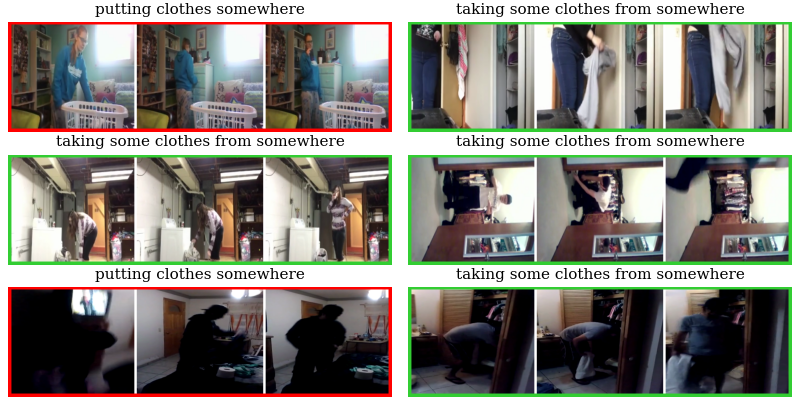

---

putting clothes somewhere

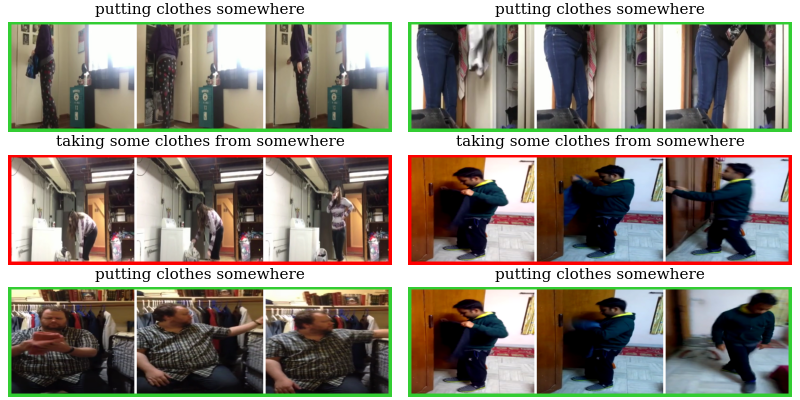

In [113]:
cids = df.chiral_triplet_id.unique()

c = np.random.choice(cids)
# c = cids[15]

subdf = df[df.chiral_triplet_id == c]

images_pos = {}
images_neg = {}
topk = 3

for k in models:
    # print(k)
    
    # Get text embedding
    zt_pos = texts_feat[k][f"{c}_1.0"]
    zt_neg = texts_feat[k][f"{c}_0.0"]
    
    text_pos = subdf[subdf.chiral_label == 1.0].template.iloc[0]
    text_neg = subdf[subdf.chiral_label == 0.0].template.iloc[0]
    
    # Get video embeddings for subdf
    zv = torch.stack(subdf.id.apply(lambda x: video_feat[k][x]).tolist())
    
    s_pos = zt_pos @ zv.T
    s_neg = zt_neg @ zv.T
    
    dfret_pos = subdf.iloc[torch.topk(s_pos, k=topk).indices]
    dfret_neg = subdf.iloc[torch.topk(s_neg, k=topk).indices]

    image_pos = show_retrieval_samples(dfret_pos.video_path.tolist(), text_pos, dfret_pos.template.tolist(), nframes=3)
    image_neg = show_retrieval_samples(dfret_neg.video_path.tolist(), text_neg, dfret_neg.template.tolist(), nframes=3)

    images_pos[k] = image_pos
    images_neg[k] = image_neg


display(Markdown(text_pos))
display(
    su.visualize.concat_images_with_border(
        [images_pos['Base'], images_pos['Fine-tuned']], border_width=0,
    )
)

display(Markdown("---"))
display(Markdown(text_neg))
display(
    su.visualize.concat_images_with_border(
        [images_neg['Base'], images_neg['Fine-tuned']], border_width=0,
    )
)

### Negation

In [114]:
# Load data
data_dir = "/scratch/shared/beegfs/piyush/datasets/NegBench"
image_dir = "/scratch/shared/beegfs/piyush/datasets/COCO2017"
csv_name_std = "images/COCO_val_retrieval.csv"
df_std = pd.read_csv(f"{data_dir}/{csv_name_std}")
csv_name_neg = "images/COCO_val_negated_retrieval_llama3.1_rephrased_affneg_true.csv"
df_neg = pd.read_csv(f"{data_dir}/{csv_name_neg}")

In [121]:
df_std['caption'] = df_std['captions'].apply(lambda x: eval(x)[0])
df_neg['caption'] = df_neg['captions'].apply(lambda x: eval(x)[0])


df_std.iloc[0].caption, df_neg.iloc[0].caption

('A man is in a kitchen making pizzas.',
 'A man in a kitchen is making pizzas, but there is no chair in sight.')

In [123]:
df_neg = df_neg.sample(n=500)
df_neg.shape

(500, 6)

In [130]:
# Compute text features
norm = lambda x: torch.nn.functional.normalize(x, dim=-1)
text_embeds = {k: {} for k in models}
for c in su.log.tqdm_iterator(df_neg.caption.unique(), desc='Computing text features'):
    for k in models:
        model = models[k]
        with torch.no_grad():
            zt = model.encode_text(c).squeeze(0).cpu().float()
            zt = norm(zt)
        text_embeds[k][c] = zt

Computing text features:   0%|          | 0/500 [00:00<?, ?it/s]

In [134]:
df_neg['image_path'] = df_neg['filepath'].apply(lambda x: x.replace('data/coco/images', image_dir))

In [135]:
# Compute image features
imag_embeds = {k: {} for k in models}
for c in su.log.tqdm_iterator(df_neg.image_path.unique(), desc='Computing image features'):
    for k in models:
        model = models[k]
        with torch.no_grad():
            zt = model.encode_image(c).squeeze(0).cpu().float()
            zt = norm(zt)
        imag_embeds[k][c] = zt

Computing image features:   0%|          | 0/500 [00:00<?, ?it/s]

In [162]:
zi = {
    k: torch.stack([imag_embeds[k][df_neg.iloc[i].image_path] for i in range(len(df_neg))]) for k in models
}
len(zi)

2

**A cat appears to be using a laptop, but there is notably no chair in the image.**

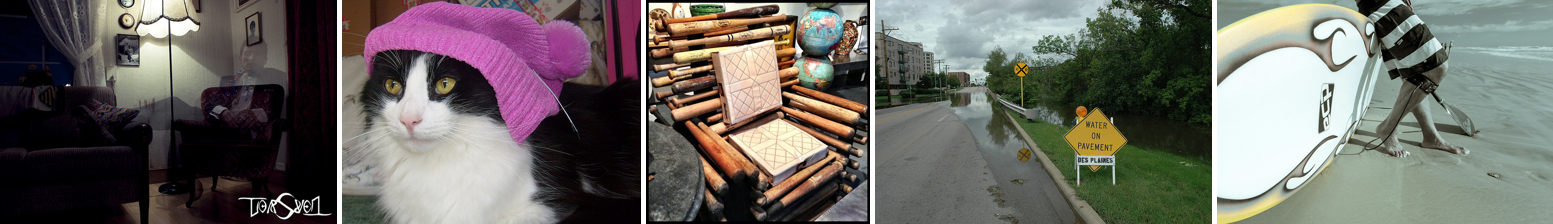

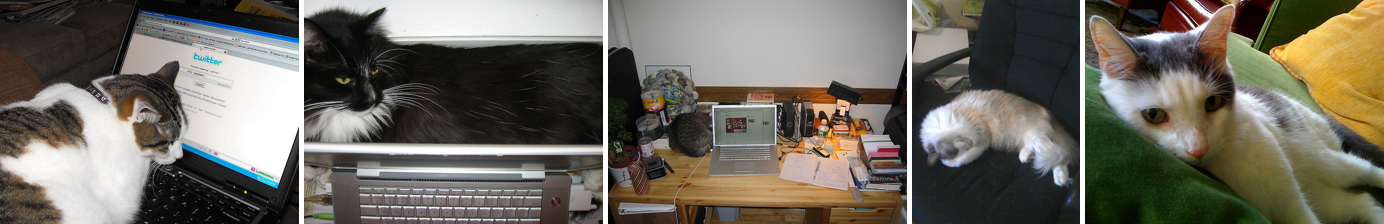

In [193]:
i = np.random.randint(len(df_neg))
row = df_neg.iloc[i].to_dict()
display(Markdown("**" + row['caption'] + "**"))

for k in models:
    zt = text_embeds[k][row['caption']]
    s = zt @ zi[k].T
    
    subdf = df_neg.iloc[torch.topk(s, k=5).indices]
    images = [su.visualize.resize_height(PIL.Image.open(f), 224) for f in subdf.image_path.tolist()]
    display(su.visualize.concat_images_with_border(images))

### CoVR